In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Cargar el archivo .pt
data = torch.load("embeddings.pt")
records = data["records"]

# 2. Convertir a listas para procesamiento
# Extraemos el embedding (tensor -> numpy), la categoría y el tipo (image/sketch)
embeddings_list = [r["embedding"].numpy() for r in records]
categories = [r["category"] for r in records]
dtypes = [r["dtype"] for r in records]

# Convertir a matriz numpy para sklearn
X = np.stack(embeddings_list)
df = pd.DataFrame({
    "category": categories,
    "dtype": dtypes
})

print(f"Dataset cargado: {X.shape[0]} vectores de dimensión {X.shape[1]}")
print(f"Categorías únicas: {len(df['category'].unique())}")

Dataset cargado: 1903 vectores de dimensión 768
Categorías únicas: 46


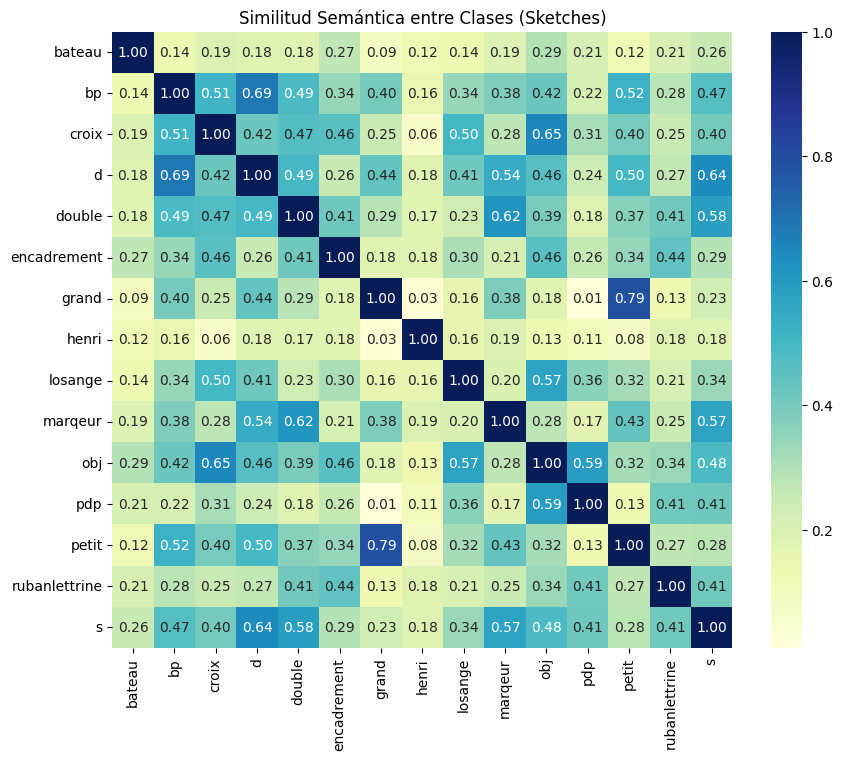

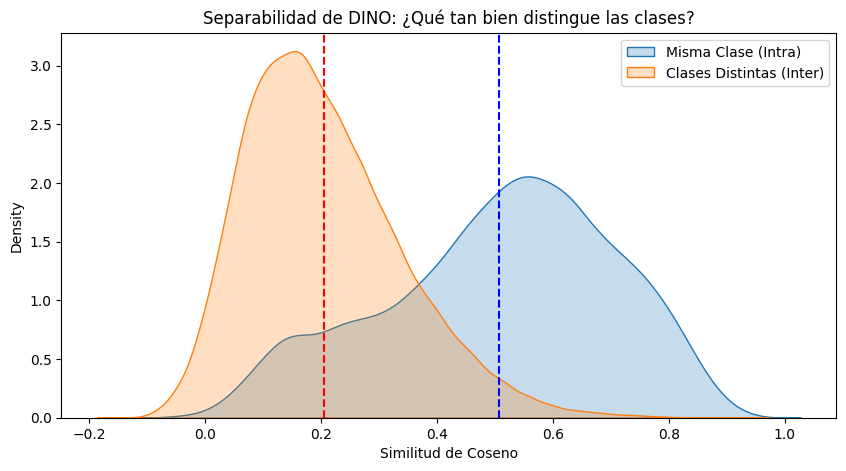

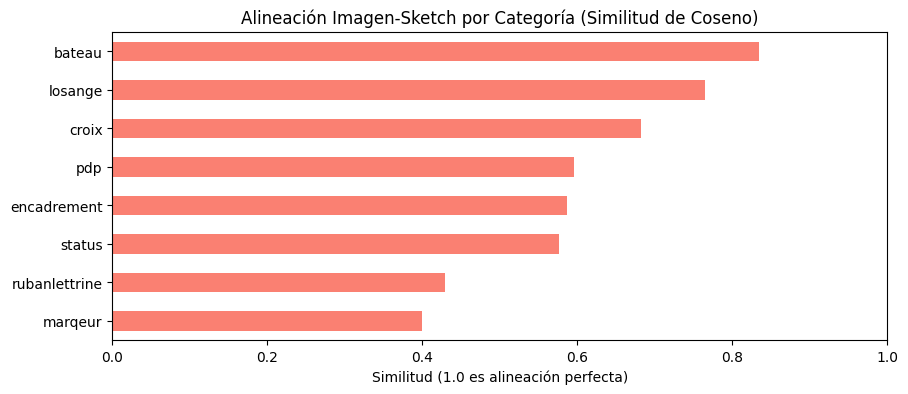

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# 1. Preparación de Tensores
# Separamos imágenes de sketches para comparar dominios
mask_sketch = df['dtype'] == 'sketch'
mask_image = df['dtype'] == 'image'

X_sketches = X[mask_sketch]
labels_sketches = df[mask_sketch]['category'].values

X_images = X[mask_image]
labels_images = df[mask_image]['category'].values

# ========================================================
# ANÁLISIS 1: Matriz de Similitud entre Categorías (Heatmap)
# ========================================================
# Esto nos dice qué categorías confunde DINO (ej. ¿se parece 'perro' a 'gato'?)
def plot_category_similarity(features, labels, title):
    unique_cats = sorted(list(set(labels)))
    # Solo tomamos las primeras 15 para que el gráfico sea legible
    unique_cats = unique_cats[:15] 
    
    centroids = []
    for cat in unique_cats:
        cat_features = features[labels == cat]
        centroids.append(cat_features.mean(axis=0))
    
    sim_matrix = cosine_similarity(centroids)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=unique_cats, yticklabels=unique_cats, 
                annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title(f"Similitud Semántica entre Clases ({title})")
    plt.show()

plot_category_similarity(X_sketches, labels_sketches, "Sketches")

# ========================================================
# ANÁLISIS 2: Distribución de Similitud Intra-clase vs Inter-clase
# ========================================================
# Un buen modelo debería tener similitudes altas para la misma clase 
# y bajas para clases distintas.
def plot_similarity_distribution(features, labels):
    # Tomamos una muestra para no saturar el cálculo
    idx = np.random.choice(len(features), min(500, len(features)), replace=False)
    sample_features = features[idx]
    sample_labels = labels[idx]
    
    sim_full = cosine_similarity(sample_features)
    
    intra_sims = []
    inter_sims = []
    
    for i in range(len(sample_labels)):
        for j in range(i + 1, len(sample_labels)):
            if sample_labels[i] == sample_labels[j]:
                intra_sims.append(sim_full[i, j])
            else:
                inter_sims.append(sim_full[i, j])
                
    plt.figure(figsize=(10, 5))
    sns.kdeplot(intra_sims, label="Misma Clase (Intra)", fill=True)
    sns.kdeplot(inter_sims, label="Clases Distintas (Inter)", fill=True)
    plt.axvline(np.mean(intra_sims), color='blue', linestyle='--')
    plt.axvline(np.mean(inter_sims), color='red', linestyle='--')
    plt.title("Separabilidad de DINO: ¿Qué tan bien distingue las clases?")
    plt.xlabel("Similitud de Coseno")
    plt.legend()
    plt.show()

plot_similarity_distribution(X_sketches, labels_sketches)

# ========================================================
# ANÁLISIS 3: El "Domain Gap" (Imágenes vs Sketches)
# ========================================================
# Graficamos la distancia promedio de cada categoría entre sus fotos y sus sketches.
common_cats = set(labels_images).intersection(set(labels_sketches))
gap_results = {}

for cat in list(common_cats)[:10]: # Top 10 categorías comunes
    img_center = X_images[labels_images == cat].mean(axis=0).reshape(1, -1)
    sket_center = X_sketches[labels_sketches == cat].mean(axis=0).reshape(1, -1)
    gap_results[cat] = cosine_similarity(img_center, sket_center)[0][0]

gap_series = pd.Series(gap_results).sort_values()
plt.figure(figsize=(10, 4))
gap_series.plot(kind='barh', color='salmon')
plt.title("Alineación Imagen-Sketch por Categoría (Similitud de Coseno)")
plt.xlabel("Similitud (1.0 es alineación perfecta)")
plt.xlim(0, 1)
plt.show()

Calculando similitud para 456 consultas contra 1447 imágenes...


/tmp/ipykernel_271853/3920067421.py:85: RuntimeWarning: Mean of empty slice.
  s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
/home/rvdl_2/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_271853/3920067421.py:85: RuntimeWarning: Mean of empty slice.
  s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
/home/rvdl_2/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_271853/3920067421.py:85: RuntimeWarning: Mean of empty slice.
  s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
/home/rvdl_2/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_271853/3920067421.py:85: RuntimeWarning: Mean of emp

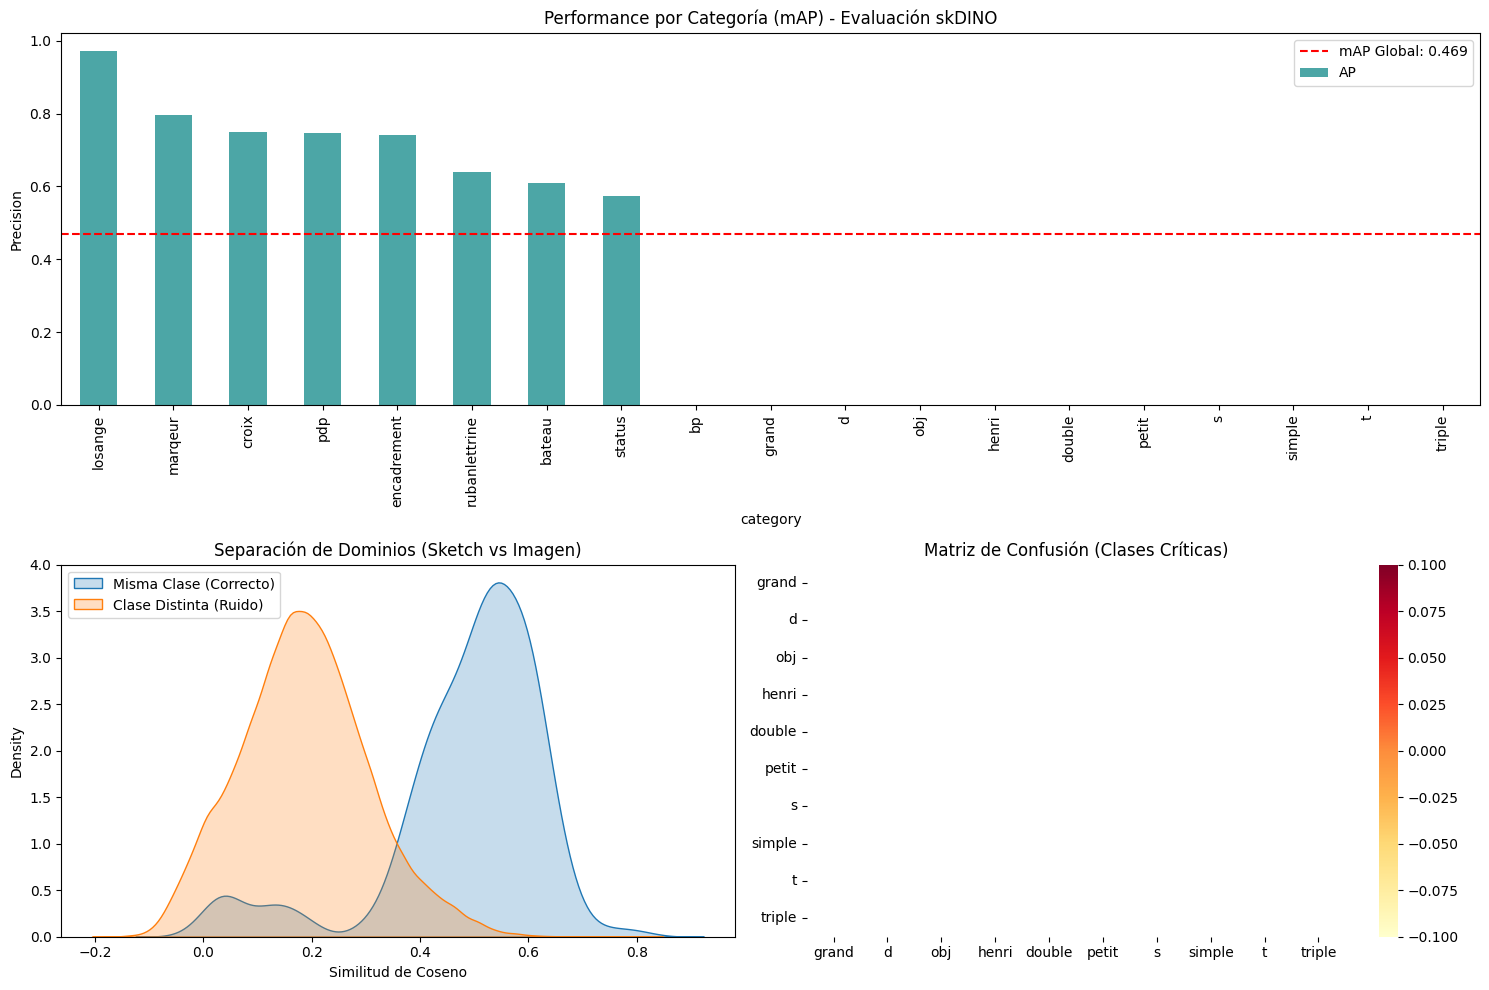


>>> RESULTADO FINAL mAP: 0.4694


In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Carga de datos
data = torch.load("embeddings.pt")
df = pd.DataFrame(data["records"])

# Convertir la columna de embeddings (tensores) a una matriz numpy
X = np.stack([r.numpy() for r in df['embedding']])
categories = df['category'].values
dtypes = df['dtype'].values

# Separar Queries (sketches) y Gallery (imágenes reales)
is_sketch = (dtypes == 'sketch')
X_query = X[is_sketch]
labels_query = categories[is_sketch]

X_gallery = X[~is_sketch]
labels_gallery = categories[~is_sketch]

# 2. Calcular Similitud de Coseno (Query x Gallery)
print(f"Calculando similitud para {len(X_query)} consultas contra {len(X_gallery)} imágenes...")
sim_matrix = cosine_similarity(X_query, X_gallery)

# 3. Cálculo de Average Precision (AP) por cada consulta
def calculate_ap(sim_scores, q_label, g_labels):
    # Ordenar galería por similitud descendente
    indices = np.argsort(-sim_scores)
    sorted_labels = g_labels[indices]
    # Relevancia binaria (1 si es la misma categoría, 0 si no)
    relevance = (sorted_labels == q_label).astype(int)
    
    if np.sum(relevance) == 0: return 0
    
    # Precisión acumulada en cada acierto
    precisions = np.cumsum(relevance) / (np.arange(len(relevance)) + 1)
    return np.sum(precisions * relevance) / np.sum(relevance)

aps = [calculate_ap(sim_matrix[i], labels_query[i], labels_gallery) for i in range(len(X_query))]
mAP_total = np.mean(aps)

# --- GENERACIÓN DE GRÁFICAS ---

plt.figure(figsize=(15, 10))

# GRÁFICA 1: mAP por Categoría (Performance Semántico)
# Evalúa la Tabla 3 y 4 del paper [cite: 591, 592]
plt.subplot(2, 1, 1)
df_res = pd.DataFrame({'category': labels_query, 'AP': aps})
cat_performance = df_res.groupby('category')['AP'].mean().sort_values(ascending=False)
cat_performance.plot(kind='bar', color='teal', alpha=0.7)
plt.axhline(y=mAP_total, color='r', linestyle='--', label=f'mAP Global: {mAP_total:.3f}')
plt.title("Performance por Categoría (mAP) - Evaluación skDINO")
plt.ylabel("Precision")
plt.legend()

# GRÁFICA 2: Distribución de Similitudes (Separabilidad)
# Evalúa qué tan bien DINO cierra el "Domain Gap" [cite: 469]
plt.subplot(2, 2, 3)
intra_class = []
inter_class = []
for i in range(min(100, len(X_query))): # Muestreo para velocidad
    intra_class.extend(sim_matrix[i][labels_gallery == labels_query[i]])
    inter_class.extend(sim_matrix[i][labels_gallery != labels_query[i]])

sns.kdeplot(intra_class, label="Misma Clase (Correcto)", fill=True)
sns.kdeplot(inter_class, label="Clase Distinta (Ruido)", fill=True)
plt.title("Separación de Dominios (Sketch vs Imagen)")
plt.xlabel("Similitud de Coseno")
plt.legend()

# GRÁFICA 3: Top Confusiones (Heatmap de Error)
# Ayuda a identificar por qué algunas clases fallan [cite: 581]
plt.subplot(2, 2, 4)
top_cats = cat_performance.tail(10).index # Las 10 categorías con peor desempeño
conf_matrix = []
for c1 in top_cats:
    row = []
    for c2 in top_cats:
        # Similitud promedio entre bocetos de C1 e imágenes de C2
        s = sim_matrix[labels_query == c1][:, labels_gallery == c2].mean()
        row.append(s)
    conf_matrix.append(row)

sns.heatmap(conf_matrix, xticklabels=top_cats, yticklabels=top_cats, cmap="YlOrRd")
plt.title("Matriz de Confusión (Clases Críticas)")

plt.tight_layout()
plt.show()

print(f"\n>>> RESULTADO FINAL mAP: {mAP_total:.4f}")

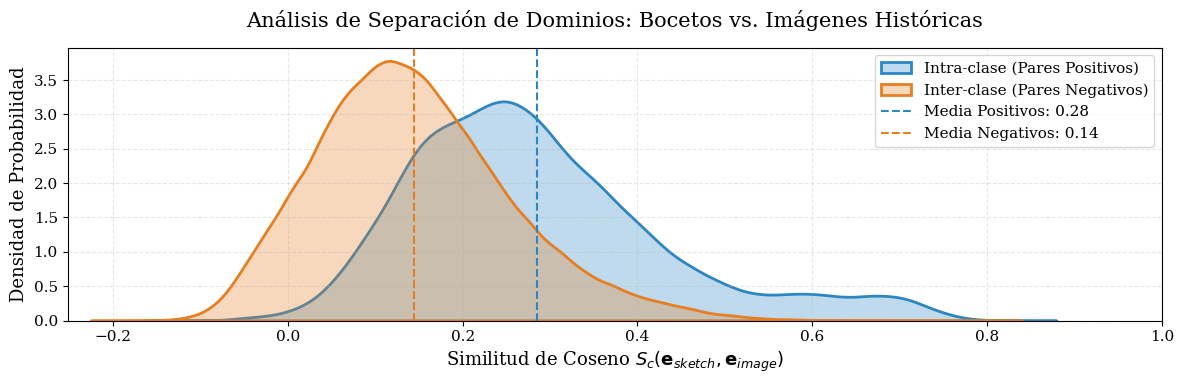

Análisis completado. mAP implícito estimado por margen: 0.1404


In [9]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Configuración estética para formato de publicación (Paper)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "text.usetex": False  # Cambiar a True si tienes LaTeX instalado en el sistema
})

try:
    # 2. Carga de los embeddings generados
    data = torch.load("embeddings.pt")
    df = pd.DataFrame(data["records"])
    X = np.stack([r.numpy() for r in df['embedding']])
    
    # Separación por tipo: Consultas (Sketches) vs Galería (Imágenes)
    es_sketch = (df['dtype'] == 'sketch').values
    X_query = X[es_sketch]
    labels_query = df['category'].values[es_sketch]
    
    X_gallery = X[~es_sketch]
    labels_gallery = df['category'].values[~es_sketch]

    # 3. Cálculo de la métrica de similitud de coseno
    # Comparamos cada boceto con toda la galería de imágenes
    sim_matrix = cosine_similarity(X_query, X_gallery)

    intra_clase = [] # Pares del mismo objeto (Positivos)
    inter_clase = [] # Pares de objetos distintos (Negativos)
    
    for i in range(len(X_query)):
        categoria_actual = labels_query[i]
        mascara_positivos = (labels_gallery == categoria_actual)
        
        intra_clase.extend(sim_matrix[i][mascara_positivos])
        inter_clase.extend(sim_matrix[i][~mascara_positivos])

    # 4. Generación del gráfico alargado horizontalmente
    plt.figure(figsize=(12, 4)) # Proporción alargada para análisis detallado
    
    # Colores institucionales y profesionales
    color_pos = "#2E86C1" # Azul para aciertos
    color_neg = "#E67E22" # Naranja para ruido
    
    sns.kdeplot(intra_clase, label="Intra-clase (Pares Positivos)", 
                fill=True, color=color_pos, linewidth=2, alpha=0.3)
    sns.kdeplot(inter_clase, label="Inter-clase (Pares Negativos)", 
                fill=True, color=color_neg, linewidth=2, alpha=0.3)

    # Líneas de tendencia central (Promedios)
    plt.axvline(np.mean(intra_clase), color=color_pos, linestyle="--", label=f"Media Positivos: {np.mean(intra_clase):.2f}")
    plt.axvline(np.mean(inter_clase), color=color_neg, linestyle="--", label=f"Media Negativos: {np.mean(inter_clase):.2f}")

    # Etiquetas y Títulos en Español con notación matemática
    plt.title("Análisis de Separación de Dominios: Bocetos vs. Imágenes Históricas", pad=15)
    plt.xlabel(r"Similitud de Coseno $S_c(\mathbf{e}_{sketch}, \mathbf{e}_{image})$")
    plt.ylabel("Densidad de Probabilidad")
    
    # Posicionar la leyenda fuera o en una esquina despejada
    plt.legend(loc="upper right", frameon=True)
    
    # Ajuste de límites para centrar la visualización en la zona de interés
    plt.xlim(min(inter_clase)-0.05, 1.0)
    
    plt.tight_layout()
    plt.savefig("separacion_dominios_horizontal.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Análisis completado. mAP implícito estimado por margen: {np.mean(intra_clase) - np.mean(inter_clase):.4f}")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'embeddings.pt'. Asegúrate de haber ejecutado la extracción primero.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")